In [1]:
import torch
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"


from src.LM.lm_slovakBERT import (
    tokenizer, model,
    create_dataloaders,
    train_model,
    evaluate_model,
    get_class_weights
)

from src.data_loader import load_data
from src.preprocess import clean_text


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at gerulata/slovakbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fine-tuning od SlovakBERT language model on NBS Binary dataset.

In [2]:
#Load data
df = load_data("/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv")
df['Text'] = df['Text'].apply(clean_text)  

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

    # ulozenie katagorii
target_names = le.classes_.tolist()

print("Target names:", target_names)
print("Label distribution:")
print(df["Category_encoded"].value_counts())


Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...
Target names: [0, 1]
Label distribution:
Category_encoded
0    505
1    189
Name: count, dtype: int64


In [3]:
# Prepare data for training
X_train_text, X_test_text, y_train_encoded, y_test_encoded = train_test_split(
    df['Text'].tolist(), 
    df['Category_encoded'].tolist(),
    test_size=0.2, 
    random_state=42,
    stratify=df['Category_encoded']
)
print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

Train size: 555
Test size: 139


In [4]:
# Create dataloaders
train_loader, test_loader = create_dataloaders(
    X_train_text,
    y_train_encoded,
    X_test_text,
    y_test_encoded,
    batch_size=16
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_weights = get_class_weights(y_train_encoded, device)
print("Class weights:", class_weights)


Class weights: tensor([0.6869, 1.8377], device='cuda:0')


Epoch 1/7, Loss: 0.1518
Epoch 2/7, Loss: 0.1087
Epoch 3/7, Loss: 0.0931
Epoch 4/7, Loss: 0.0791
Epoch 5/7, Loss: 0.0567
Epoch 6/7, Loss: 0.0364
Epoch 7/7, Loss: 0.0356
Best threshold (F1-optimal): 0.729
Best F1 score: 0.757| Precision: 0.778 | Recall: 0.737

Recall-optimal threshold: 0.351
F1: 0.655 | Precision: 0.500 | Recall: 0.947
              precision    recall  f1-score   support

           0       0.97      0.64      0.77       101
           1       0.50      0.95      0.65        38

    accuracy                           0.73       139
   macro avg       0.74      0.80      0.71       139
weighted avg       0.84      0.73      0.74       139



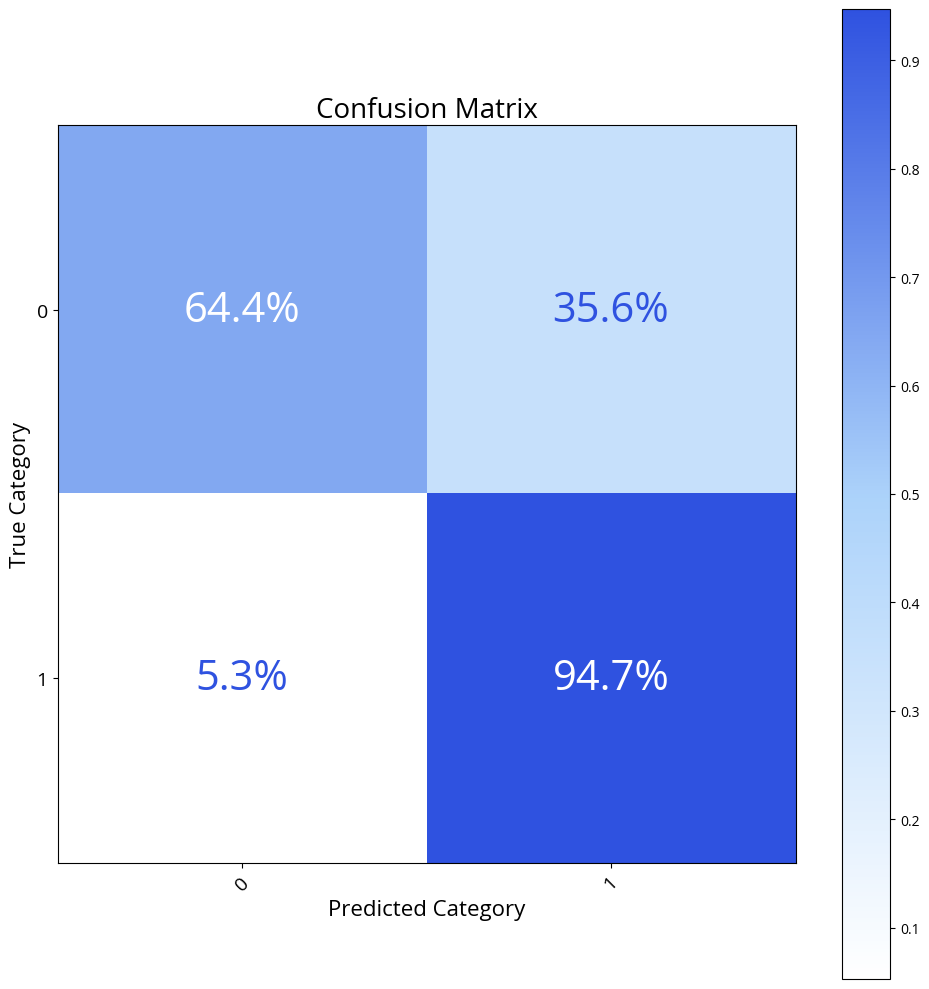

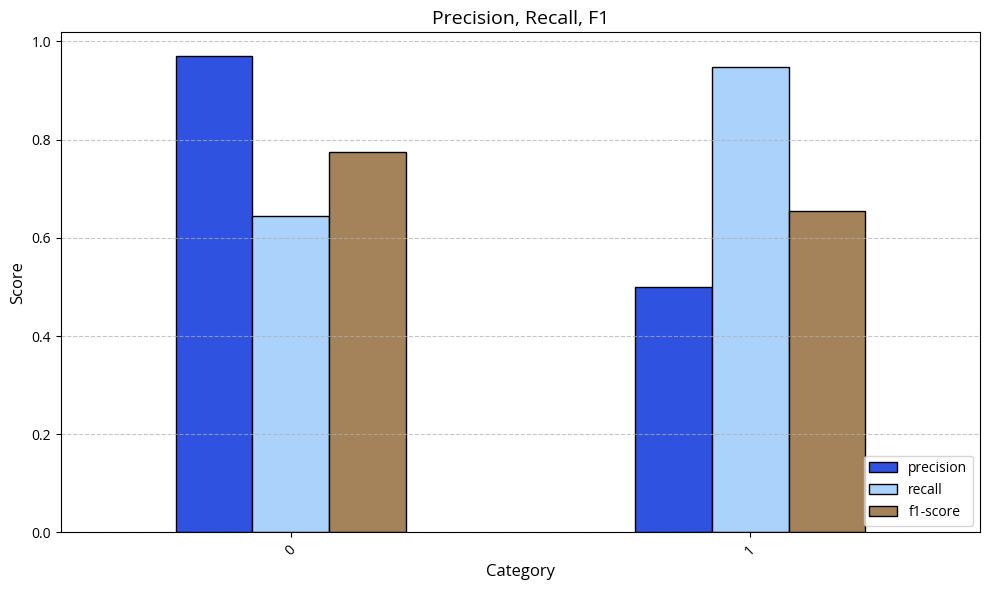

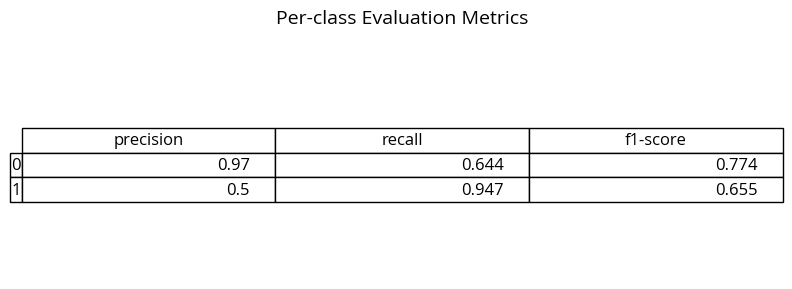

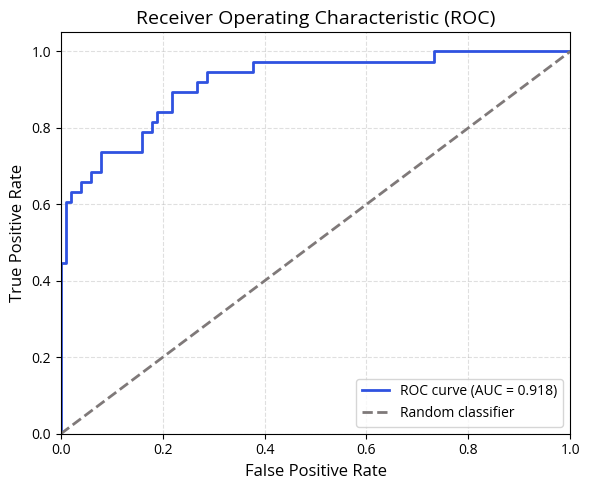

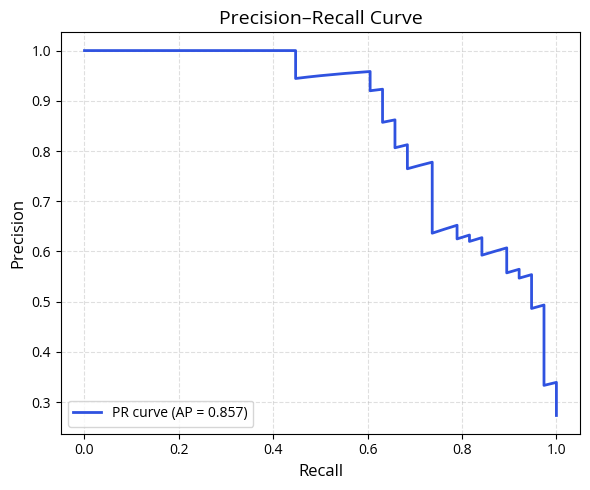

In [5]:
#Training of SlovakBERT model
trained_model = train_model(
    model,
    train_loader,
    epochs=7,
    lr=1e-5, 
    use_focal_loss=True,
    class_weights=class_weights
)

trained_model.save_pretrained("models/slovakBert_binary")
tokenizer.save_pretrained("models/slovakBert_binary")

evaluate_model(
    trained_model,
    test_loader,
    label_names=target_names
)
